График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/wss.png


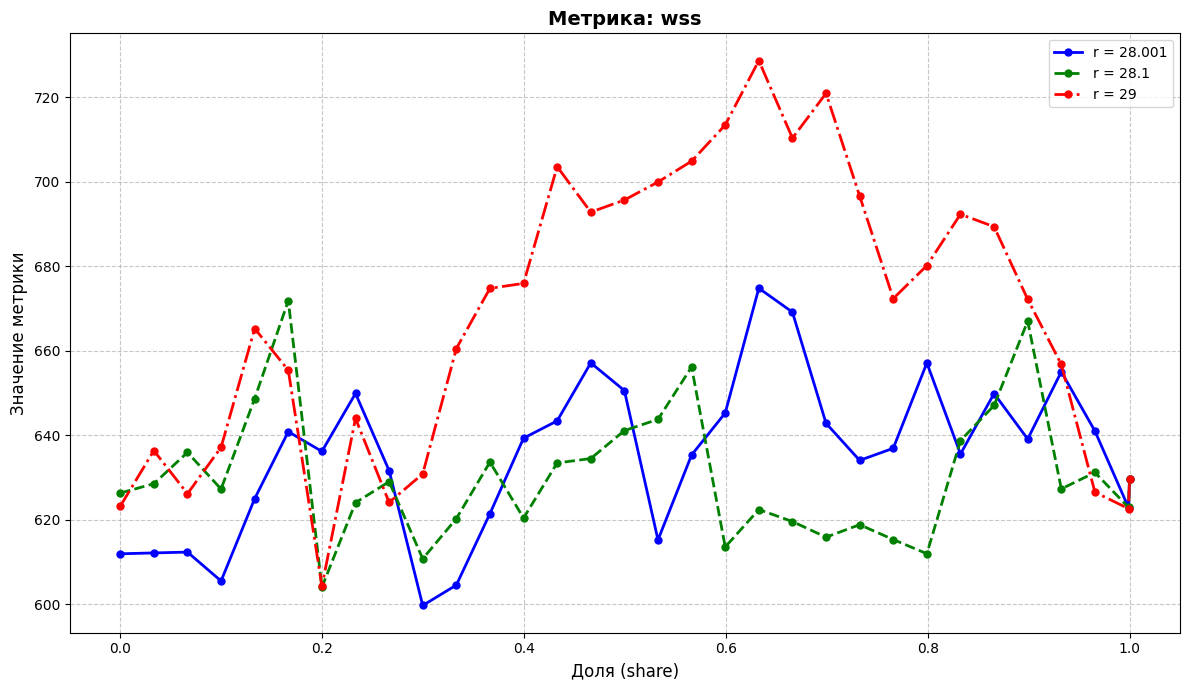

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/r2.png


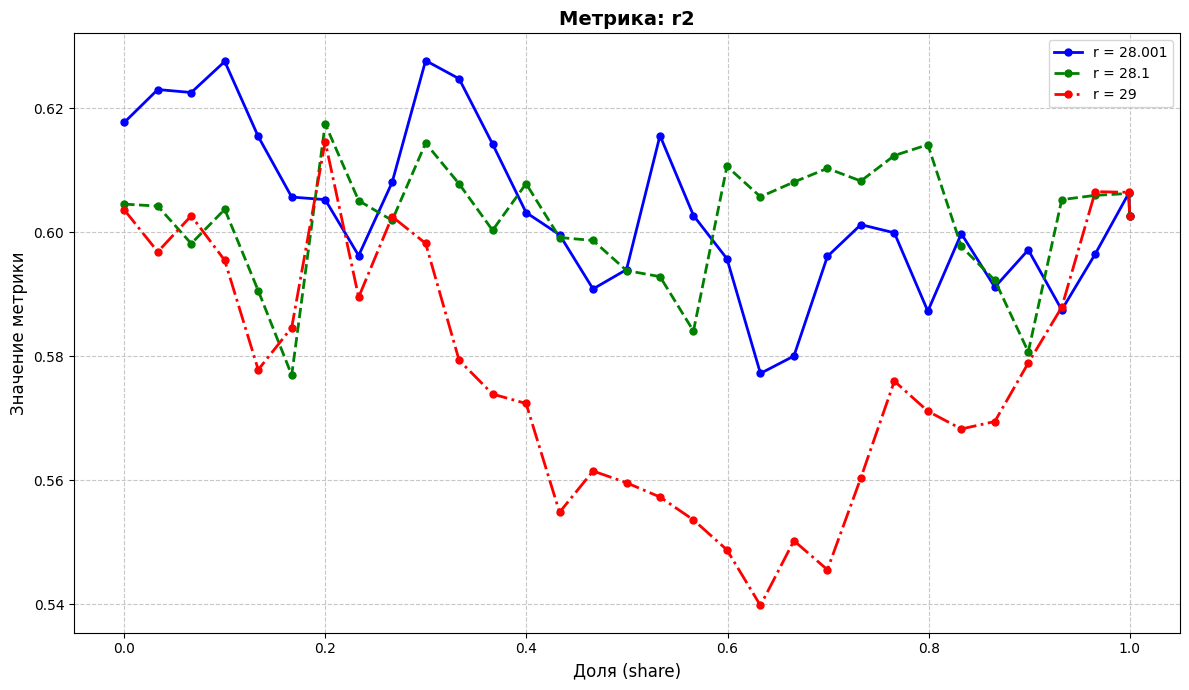

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/calinski_harabasz.png


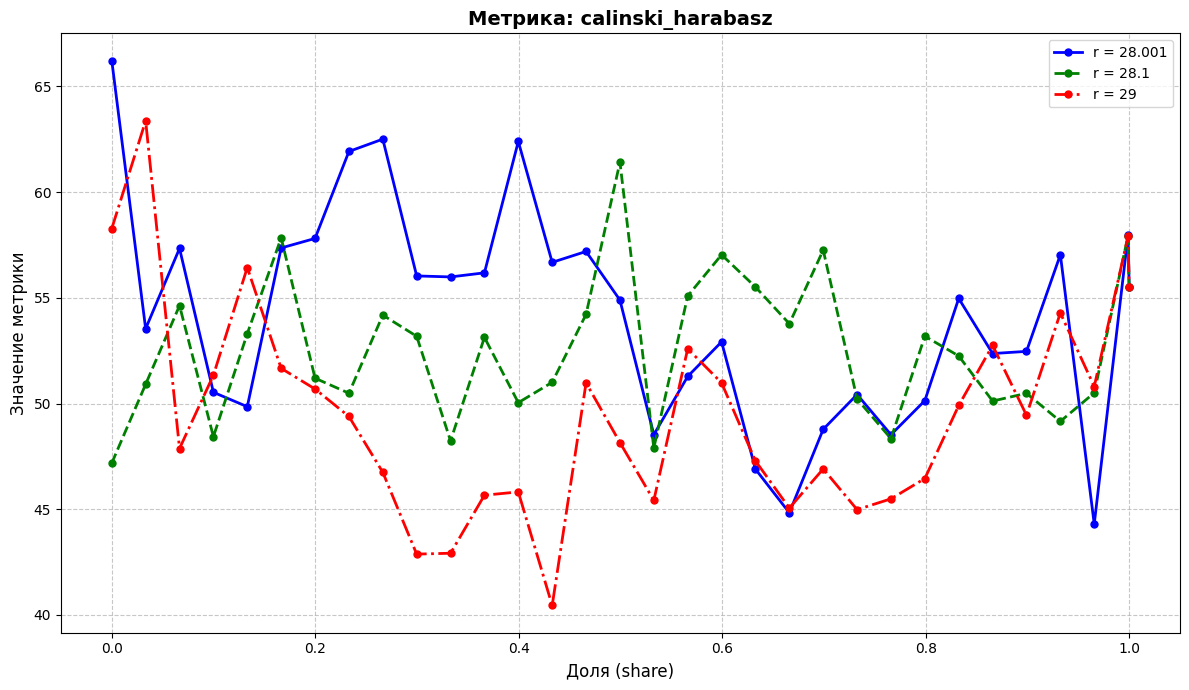

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/xie_beni.png


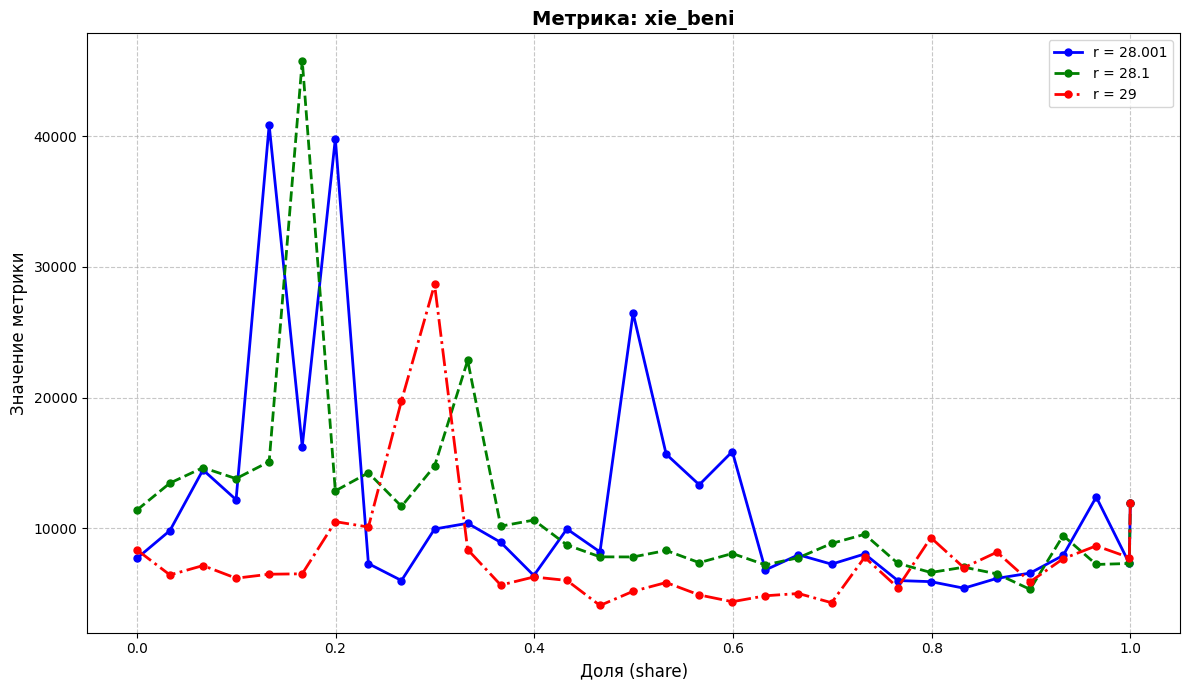

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/davies_bouldin.png


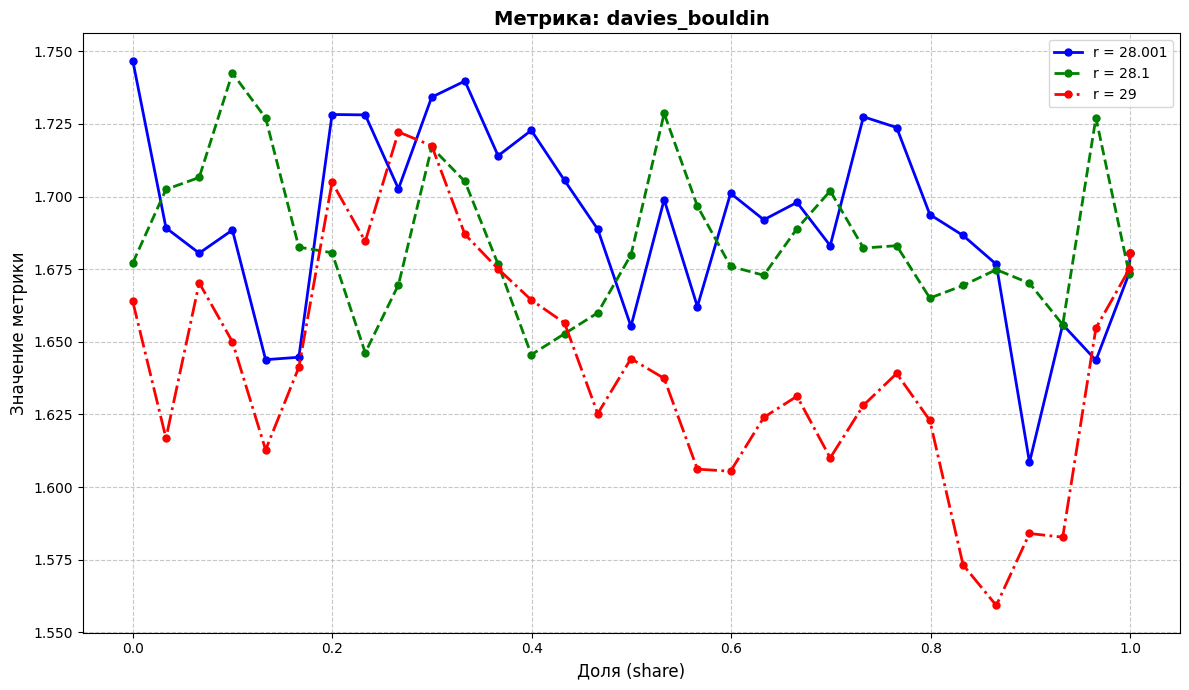

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/sd_index.png


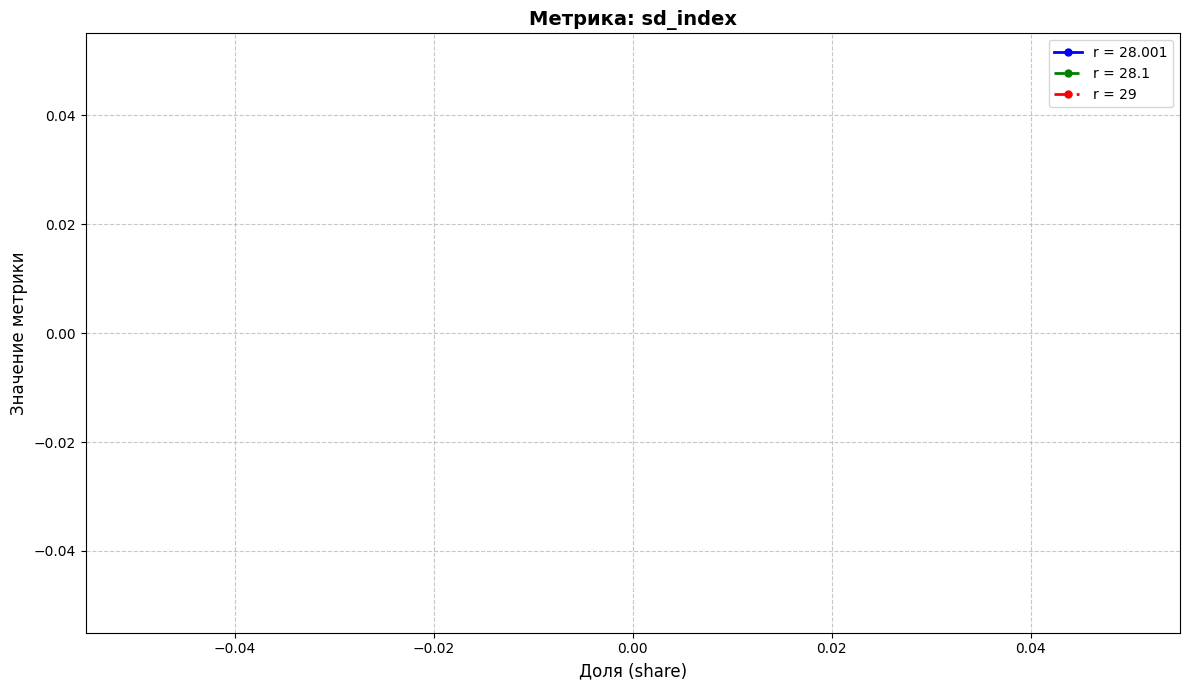

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/noise_percentage.png


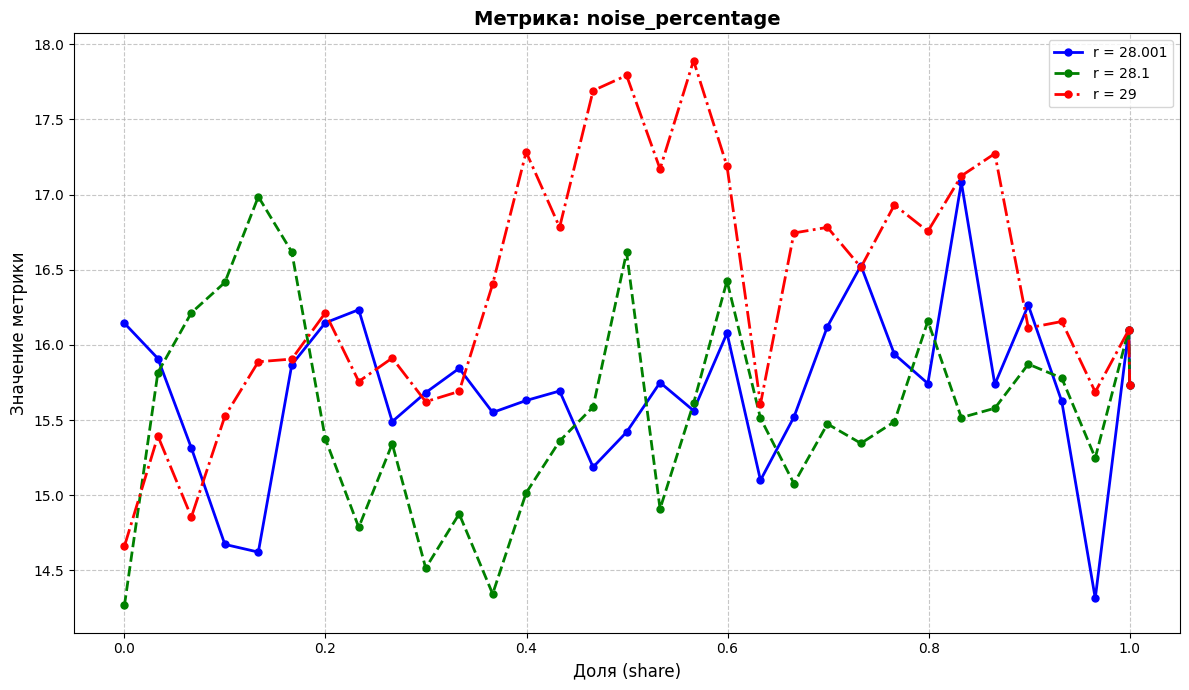

График сохранён как: /home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/avg_cluster_size.png


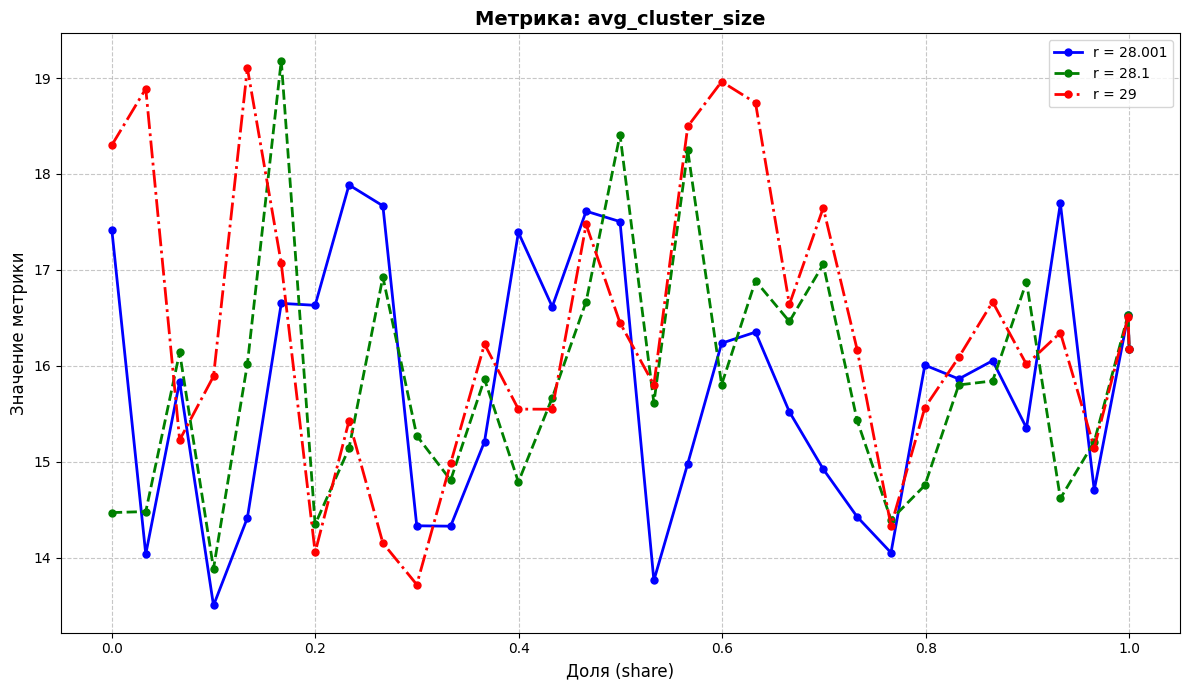

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import os

def plot_metric_results(filename, metric_name=None, show=True, save=True):
    """
    Визуализирует результаты метрик из файла

    Параметры:
    filename (str): путь к файлу с данными
    metric_name (str): название метрики для заголовка
    show (bool): показывать график на экране
    save (bool): сохранять график в файл
    """
    # Проверка существования файла
    if not os.path.exists(filename):
        print(f"Файл не найден: {filename}")
        return

    # Чтение данных из файла
    with open(filename, 'r') as f:
        content = f.read().strip()

    # Разделение на блоки данных
    blocks = content.split("share,metric_value\n")[1:]

    # Проверка количества блоков
    if len(blocks) != 3:
        print(f"Неверный формат данных в файле {filename}. Ожидается 3 блока.")
        return

    # Параметры отклонений
    deviations = [0.001, 0.1, 1]
    colors = ['blue', 'green', 'red']
    line_styles = ['-', '--', '-.']

    # Создание графика
    plt.figure(figsize=(12, 7))

    for i, block in enumerate(blocks):
        # Обработка каждого блока данных
        lines = block.strip().split('\n')
        shares = []
        values = []

        for line in lines:
            # Пропуск пустых строк
            if not line.strip():
                continue
            try:
                s, v = line.split(',')
                shares.append(float(s))
                values.append(float(v))
            except ValueError:
                print(f"Ошибка формата в строке: {line}")
                continue

        # Сортировка по значению share
        sorted_data = sorted(zip(shares, values))
        shares_sorted, values_sorted = zip(*sorted_data)

        # Построение графика для текущего отклонения
        plt.plot(shares_sorted, values_sorted,
                 color=colors[i], linestyle=line_styles[i],
                 marker='o', markersize=5, linewidth=2,
                 label=f'r = {28+deviations[i]}')

    # Настройки графика
    title = f'Метрика: {metric_name}' if metric_name else 'Сравнение метрик'
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Доля (share)', fontsize=12)
    plt.ylabel('Значение метрики', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()

    # Сохранение графика
    if save:
        output_filename = filename.replace('.txt', '.png')
        plt.savefig(output_filename, dpi=300, bbox_inches='tight')
        print(f"График сохранён как: {output_filename}")

    # Показ графика
    if show:
        plt.show()
    else:
        plt.close()


# Пример использования:
if __name__ == "__main__":
    # Для каждой метрики вызываем функцию
    metrics = [
        "wss",
        "r2",
        "calinski_harabasz",
        "xie_beni",
        "davies_bouldin",
        "sd_index",
        "noise_percentage",
        "avg_cluster_size"
    ]

    for metric in metrics:
        filename = f"/home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/{metric}.txt"
        plot_metric_results(filename, metric)

IndexError: list index out of range

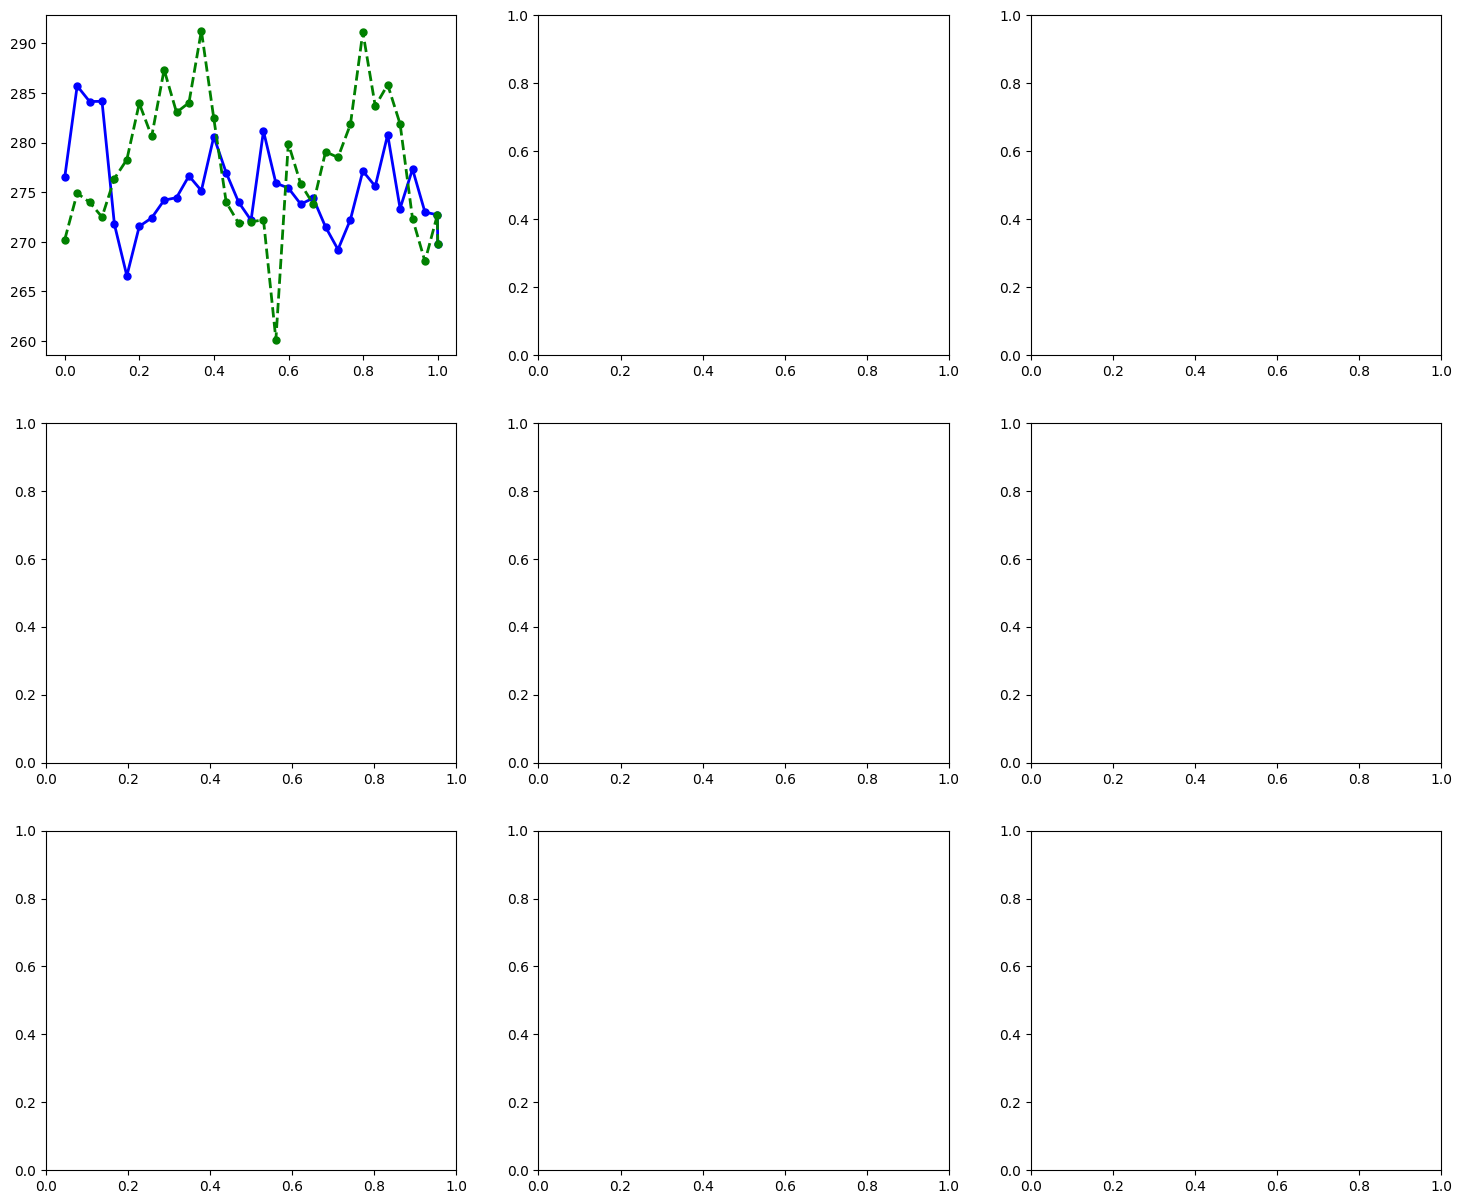

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_metric_results_on_ax(filename, ax, metric_name=None):
    """
    Визуализирует результаты метрик из файла на заданной оси

    Параметры:
    filename (str): путь к файлу с данными
    ax (matplotlib.axes.Axes): ось для построения графика
    metric_name (str): название метрики для заголовка
    """
    # Проверка существования файла
    if not os.path.exists(filename):
        print(f"Файл не найден: {filename}")
        return

    # Чтение данных из файла
    with open(filename, 'r') as f:
        content = f.read().strip()

    # Разделение на блоки данных
    blocks = content.split("share,metric_value\n")[1:]

    # Проверка количества блоков
    if len(blocks) != 3:
        print(f"Неверный формат данных в файле {filename}. Ожидается 2 блока.")
        return

    # Параметры отклонений
    deviations = [0.001, 0.1,1]
    colors = ['blue', 'green']
    line_styles = ['-', '--']

    for i, block in enumerate(blocks):
        # Обработка каждого блока данных
        lines = block.strip().split('\n')
        shares = []
        values = []

        for line in lines:
            # Пропуск пустых строк
            if not line.strip():
                continue
            try:
                s, v = line.split(',')
                shares.append(float(s))
                values.append(float(v))
            except ValueError:
                print(f"Ошибка формата в строке: {line}")
                continue

        # Сортировка по значению share
        sorted_data = sorted(zip(shares, values))
        shares_sorted, values_sorted = zip(*sorted_data)

        # Построение графика для текущего отклонения
        ax.plot(shares_sorted, values_sorted,
                 color=colors[i], linestyle=line_styles[i],
                 marker='o', markersize=5, linewidth=2,
                 label=f'r = {28 + deviations[i]}')

    # Настройки графика
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Доля (share)', fontsize=10)
    ax.set_ylabel('Значение метрики', fontsize=10)
    
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)


if __name__ == "__main__":
    # Список метрик
    metrics = [
        "calinski_harabasz",
        "xie_beni",
        "davies_bouldin",
        "noise_percentage",
        "avg_cluster_size",
        "r2",
        "wss"
    ]
    
    # Создаем фигуру с сеткой 3x3
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.flatten()  # Преобразуем в одномерный массив для удобства
    
    # Строим графики для каждой метрики
    for i, metric in enumerate(metrics):
        filename = f"/home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/{metric}.txt"
        plot_metric_results_on_ax(filename, axes[i], metric_name=metric)
    
    # Скрываем последнюю пустую ячейку
    if len(metrics) < len(axes):
        axes[len(metrics)].axis('off')
    
    # Общие настройки и сохранение
    plt.tight_layout(pad=3.0)
    plt.savefig("/home/yarik/Gromov/PaTHoP/assets/results/metrics_experiment/all_metrics_grid.png", 
                dpi=300, bbox_inches='tight')
    plt.show()